# Phase 3.0 — Naive Benchmark Model (Seasonal Persistence t-168)

**Thesis:** Comparison of algorithms for electricity demand prediction  
**Author:** Antonio Navarro  

This notebook implements the **Seasonal Naive Benchmark** ($t-168$ hours = 7 days):
$$\hat{y}_t = y_{t-168}$$

### Why this benchmark?
1. **Power sector standard:** Electricity demand shows a strong weekly periodicity (168 hours). Behavior on a Monday at 11:00 AM is usually very similar to the previous Monday at 11:00 AM.
2. **Baseline floor:** Any advanced model (SARIMAX, LSTM, Tiny Time Mixers) must outperform this benchmark to demonstrate real value beyond simple persistence.
3. **Zero training cost:** A deterministic model with no learned parameters (`train_time = 0.0 s`).
4. **Standardized export:** Saves predictions to `data/predictions_naive.csv` and metrics to `data/metrics_naive.json` for the unified Phase 3 comparison.

In [1]:
import sys, os, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── Colab: clone or update the repo, then cd into it ──────────────────────────
REPO_NAME = "pred_demanda"
REPO_URL  = "https://github.com/antonionc/pred_demanda.git"

if os.path.exists("data_utils.py"):
    !git pull
elif os.path.isdir(REPO_NAME):
    %cd {REPO_NAME}
    !git pull
elif os.path.exists(f"/content/{REPO_NAME}"):
    %cd /content/{REPO_NAME}
    !git pull
elif os.path.exists("/content"):
    !git clone {REPO_URL}
    %cd {REPO_NAME}
# ──────────────────────────────────────────────────────────────────────────────

sys.path.insert(0, os.path.abspath('.'))
import data_utils as du

# Mount Google Drive in Colab and create persistent links for data/, cache/, saved_models/
du.setup_colab_drive()

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
sns.set_theme(style='whitegrid')
print('Environment ready.')

Cloning into 'pred_demanda'...
remote: Enumerating objects: 149, done.
remote: Counting objects: 100% (149/149), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 149 (delta 86), reused 85 (delta 36), pack-reused 0 (from 0)
Receiving objects: 100% (149/149), 4.35 MiB | 13.75 MiB/s, done.
Resolving deltas: 100% (86/86), done.
/content/pred_demanda
[Colab] Requesting scoped access to Google Drive ('drive.file')...


  [DriveSync] Downloading data/fig_ttm_fewshot_week.png...
  [DriveSync] Downloading data/fig_ttm_zeroshot_week.png...
  [DriveSync] Downloading data/fig_pearson_correlation.png...
  [DriveSync] Downloading data/fig_naive_week_zoom.png...
  [DriveSync] Downloading data/fig_computational_efficiency.png...
  [DriveSync] Downloading data/metrics_ttm_fewshot.json...
  [DriveSync] Downloading data/fig_naive_full_year.png...
  [DriveSync] Downloading data/fig_lstm_test.png...
  [DriveSync] Downloading data/fig_stl_decomposition.png...
  [DriveSync] Downloading data/fig_ttm_comparison_week.png...
  [DriveSync] Downloading data/features_test.csv...
  [DriveSync] Downloading data/fig_data_split.png...
  [DriveSync] Downloading data/predictions_naive.csv...
  [DriveSync] Downloading data/features_val.csv...
  [DriveSync] Downloading data/predictions_sarimax.csv...
  [DriveSync] Downloading data/fig_acf_pacf.png...
  [DriveSync] Downloading data/fig_sarimax_week.png...
  [DriveSync] Downloading d

## 1 · Load Data

We load the training, validation, and test datasets generated in Phase 1.

In [2]:
TARGET_COL = "demand_mw"

df_train = pd.read_csv("data/features_train.csv", parse_dates=["datetime"])
df_val   = pd.read_csv("data/features_val.csv",   parse_dates=["datetime"])
df_test  = pd.read_csv("data/features_test.csv",  parse_dates=["datetime"])

print(f"Train : {len(df_train):,} rows ({df_train['datetime'].min().date()} → {df_train['datetime'].max().date()})")
print(f"Val   : {len(df_val):,} rows ({df_val['datetime'].min().date()} → {df_val['datetime'].max().date()})")
print(f"Test  : {len(df_test):,} rows ({df_test['datetime'].min().date()} → {df_test['datetime'].max().date()})")

Train : 29,259 rows (2020-01-08 → 2023-05-11)
Val   : 9,753 rows (2023-05-11 → 2024-06-20)
Test  : 9,754 rows (2024-06-20 → 2025-07-31)


## 2 · Generate Naive Model Predictions (t-168)

For any instant $t$ in the test set, the prediction is the actual value observed exactly 168 hours earlier:
$$\hat{y}_t = y_{t-168}$$

We concatenate the last week of the validation set with the test set so that the first 168 hours of the test set have their previous history available without generating null values (`NaN`).

In [3]:
t0 = time.time()

# Concatenate the last week of validation with the test set for a continuous lag
df_eval_stream = pd.concat([
    df_val.tail(168)[["datetime", TARGET_COL]],
    df_test[["datetime", TARGET_COL]],
], ignore_index=True).sort_values("datetime").reset_index(drop=True)

# Generate the Naive t-168 prediction
df_eval_stream["y_pred_naive"] = df_eval_stream[TARGET_COL].shift(168)

# Strictly filter for the dates in the test set
test_dates = set(df_test["datetime"])
df_naive_test = df_eval_stream[df_eval_stream["datetime"].isin(test_dates)].copy().reset_index(drop=True)

inference_time = time.time() - t0

y_true = df_naive_test[TARGET_COL].values
y_pred = df_naive_test["y_pred_naive"].values
dates  = pd.to_datetime(df_naive_test["datetime"])

print(f"Predictions generated in {inference_time:.4f} s ({len(df_naive_test):,} observations)")
assert not np.isnan(y_pred).any(), "Error: NaN values exist in naive predictions!"

Predictions generated in 0.0554 s (9,754 observations)


## 3 · Metrics Evaluation

We calculate MAPE (%), RMSE (MW), and MAE (MW) on the full test set.

In [4]:
metrics_naive = du.compute_metrics(y_true, y_pred, label="Naive t-168")
metrics_naive["train_s"]     = 0.0
metrics_naive["inference_s"] = inference_time

print("--- Naive Benchmark Metrics Summary ---")
print(f"MAPE : {metrics_naive['mape']:.3f} %")
print(f"RMSE : {metrics_naive['rmse']:.1f} MW")
print(f"MAE  : {metrics_naive['mae']:.1f} MW")
print(f"Training time  : {metrics_naive['train_s']:.1f} s")
print(f"Inference time : {metrics_naive['inference_s']:.4f} s")

[Naive t-168] MAPE=6.560%  RMSE=2243.4 MW  MAE=1445.9 MW
--- Naive Benchmark Metrics Summary ---
MAPE : 6.560 %
RMSE : 2243.4 MW
MAE  : 1445.9 MW
Training time  : 0.0 s
Inference time : 0.0554 s


## 4 · Benchmark Visualizations

1. Full time series for the test year.
2. Representative 1-week zoom (7 days).
3. Error and scatter analysis (Actual vs Predicted).

Figure saved → data/fig_naive_full_year.png


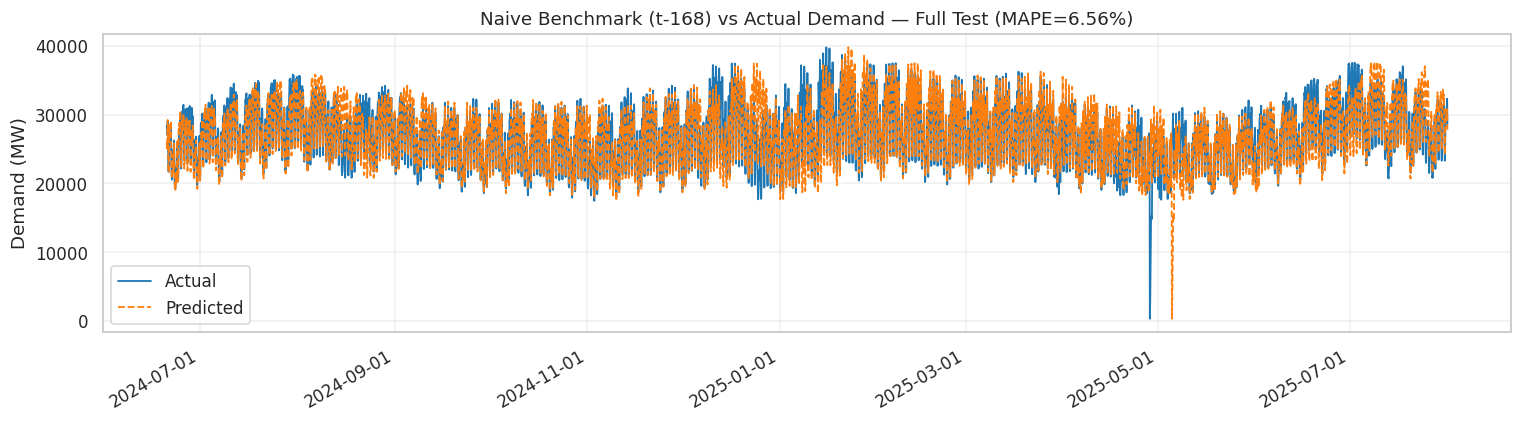

In [5]:
# 1. Full year visualization
du.plot_predictions(
    y_true    = y_true,
    y_pred    = y_pred,
    dates     = dates,
    title     = f"Naive Benchmark (t-168) vs Actual Demand — Full Test (MAPE={metrics_naive['mape']:.2f}%)",
    save_path = "data/fig_naive_full_year.png",
)

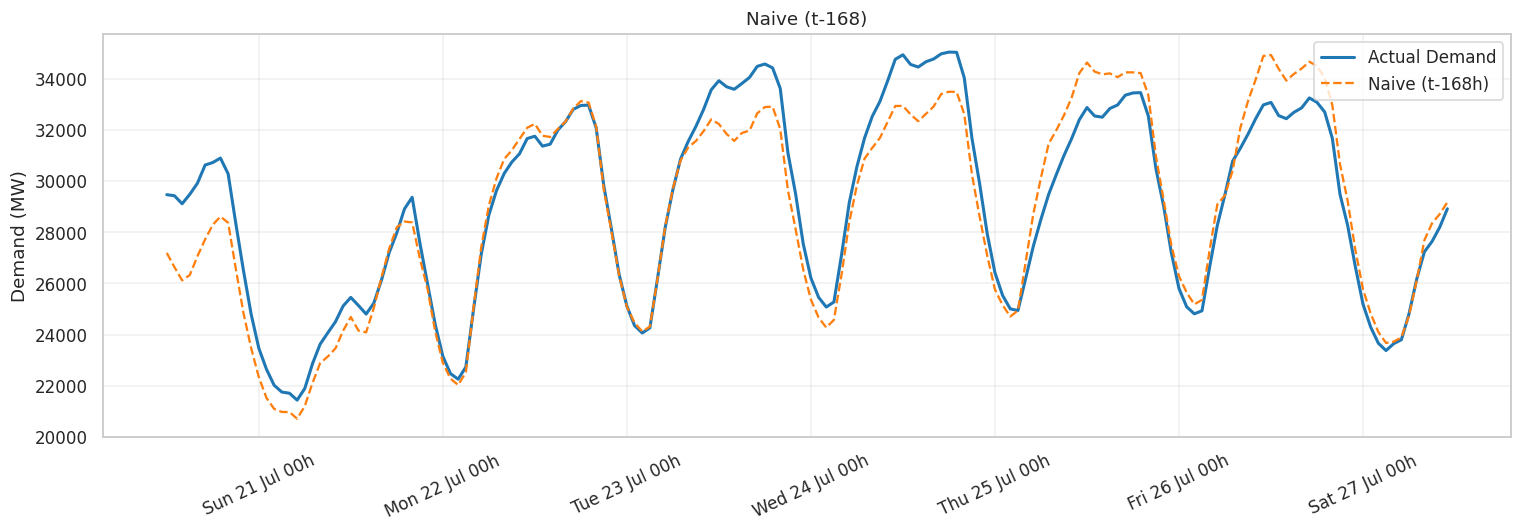

In [6]:
# 2. Representative 1-week zoom (168 hours = 7 days)
PLOT_DAYS  = 7
PLOT_START = dates.min() + pd.Timedelta(days=30)  # Week starting 1 month into test set
PLOT_END   = PLOT_START + pd.Timedelta(days=PLOT_DAYS)

mask = (dates >= PLOT_START) & (dates < PLOT_END)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates[mask], y_true[mask], label="Actual Demand", color="#1f77b4", linewidth=2.0)
ax.plot(dates[mask], y_pred[mask], label="Naive (t-168h)", color="#ff7f0e", linewidth=1.5, linestyle="--")

ax.set_title(f"Naive (t-168)")
ax.set_ylabel("Demand (MW)")
ax.legend(loc="upper right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b %Hh"))
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig("data/fig_naive_week_zoom.png", dpi=150, bbox_inches="tight")
plt.show()

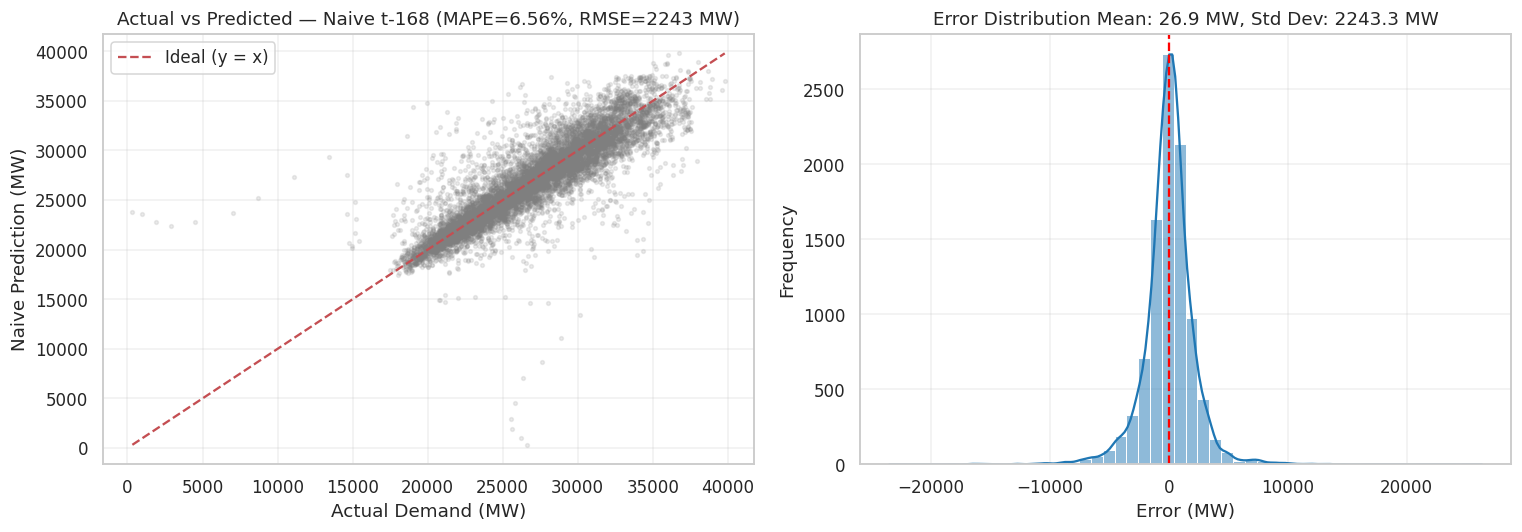

In [7]:
# 3. Actual vs Predicted scatter and error distribution
errors = y_true - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_true, y_pred, alpha=0.15, s=6, color="#7f7f7f")
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label="Ideal (y = x)")
axes[0].set_title(f"Actual vs Predicted — Naive t-168 (MAPE={metrics_naive['mape']:.2f}%, RMSE={metrics_naive['rmse']:.0f} MW)")
axes[0].set_xlabel("Actual Demand (MW)")
axes[0].set_ylabel("Naive Prediction (MW)")
axes[0].legend()

# Residuals histogram
sns.histplot(errors, kde=True, ax=axes[1], color="#1f77b4", bins=50)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title(f"Error Distribution Mean: {errors.mean():.1f} MW, Std Dev: {errors.std():.1f} MW")
axes[1].set_xlabel("Error (MW)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("data/fig_naive_scatter_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

## 5 · Save Predictions and Metrics for Phase 3

We save the predictions and metrics using the same standardized names and formats as SARIMAX, LSTM, and TTM.

In [8]:
# Save predictions to CSV
df_preds = pd.DataFrame({
    "datetime": dates,
    "y_true":   y_true,
    "y_pred":   y_pred,
})
df_preds.to_csv("data/predictions_naive.csv", index=False)
print(f"Saved {len(df_preds):,} predictions → data/predictions_naive.csv")

# Save metrics to JSON
metrics_to_save = {
    "mape":        round(metrics_naive["mape"], 3),
    "rmse":        round(metrics_naive["rmse"], 1),
    "mae":         round(metrics_naive["mae"], 1),
    "train_s":     0.0,
    "inference_s": round(metrics_naive["inference_s"], 4),
}

with open("data/metrics_naive.json", "w") as f:
    json.dump(metrics_to_save, f, indent=2)
print("Saved metrics → data/metrics_naive.json")
print(metrics_to_save)

# Sync with Google Drive in Colab
du.sync_to_drive()

Saved 9,754 predictions → data/predictions_naive.csv
Saved metrics → data/metrics_naive.json
{'mape': 6.56, 'rmse': 2243.4, 'mae': 1445.9, 'train_s': 0.0, 'inference_s': 0.0554}
  [DriveSync] Uploading data/fig_sarimax_test.png to Drive...
  [DriveSync] Uploading data/fig_lstm_residuals.png to Drive...
  [DriveSync] Uploading data/fig_naive_scatter_residuals.png to Drive...
  [DriveSync] Uploading data/metrics_lstm.json to Drive...
  [DriveSync] Uploading data/predictions_lstm.csv to Drive...
  [DriveSync] Uploading data/comparison_table.csv to Drive...
  [DriveSync] Uploading data/fig_boxcox.png to Drive...
  [DriveSync] Uploading data/fig_seasonality.png to Drive...
  [DriveSync] Uploading data/fig_all_models_week.png to Drive...
  [DriveSync] Uploading data/fig_ttm_finetune.png to Drive...
  [DriveSync] Uploading data/fig_comparison_table.png to Drive...
  [DriveSync] Uploading data/fig_scatter_all_models.png to Drive...
  [DriveSync] Uploading data/fig_metrics_comparison.png to Dri

True

## 6 · Benchmark Summary and Conclusions

The Naive weekly persistence model ($t-168$) provides the fundamental baseline reference for the project:

| Model | MAPE (%) | RMSE (MW) | MAE (MW) | Training Time | Inference Time |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Naive (t-168)** | *(see above)* | *(see above)* | *(see above)* | **0.0 s** | **< 0.05 s** |

---
Next step → Run `fase3_validacion_y_comparativa.ipynb` to compare this benchmark against SARIMAX, LSTM, and TTM.

In [9]:
#Terminate runtime
from google.colab import runtime
runtime.unassign()